# Exercise 3 : GradCAM

1. **Model with GradCAM**

Implement GradCAM for a model (2 CNN Layers, 1 dense layer) with the last layer of the CNN-stack to define the GradCAM.



In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
class Model():
    def __init__(self):
        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.flatten = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 7 * 7, 10),
        )
        self.model = torch.nn.Sequential(self.conv1, self.conv2, self.flatten)

2. **Dataset**

In [ ]:
training_data = datasets.FashionMNIST(root="./data",
                               train=True,
                               download=True,
                               transform=ToTensor())

test_data = datasets.FashionMNIST(root="./data",
                           train=False,
                           download=True,
                           transform=ToTensor())

classes = training_data.classes
print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


3. **Training**

In [ ]:
def train(m, epochs=5, batch_size=128):
    train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=2)
    optimizer    = torch.optim.Adam(m.model.parameters(), lr=1e-3)
    ce_loss      = torch.nn.CrossEntropyLoss()

    m.model.train()
    for epoch in range(epochs):
        total_loss, correct, n = 0.0, 0, 0
        for x, y in train_loader:
            optimizer.zero_grad()
            logits = m.model(x)
            loss   = ce_loss(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            n += len(y)

        print(f"Epoch {epoch}  loss : {total_loss/n:.4f}  acc : {correct/n:.2%}")

4. **GradCAM**

In [ ]:
def gradcam(m, x):
    store = {}

    def save_feat(mod, i, o):
        store["feat"] = o
        o.retain_grad()     # keep the grad in memory after the .backward()

    def save_grad(mod, i, o):
        store["grad"] = o[0].detach()

    hook1 = m.conv2.register_forward_hook(save_feat)    # gradcam on the last conv layer
    hook2 = m.conv2.register_full_backward_hook(save_grad)

    logits = m.model(x.requires_grad_(True))
    m.model.zero_grad()
    logits[0, logits.argmax()].backward()

    hook1.remove()
    hook2.remove()

    weights = store["feat"][0].mean(dim=(1, 2))
    cam     = (weights[:, None, None] * store["feat"][0]).sum(0)
    cam     = torch.nn.functional.relu(cam)

    if cam.sum() == 0:      # avoid 0 in relu
        cam = (weights[:, None, None].abs() * store["feat"][0]).sum(0)

    cam = torch.nn.functional.interpolate(cam[None, None], (28, 28), mode="bilinear", align_corners=False).squeeze()
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    return cam.detach().numpy(), int(logits.argmax())

5. **Analysis**

Analyse the results for some selected images (for each class at least one sample).

In [ ]:
m = Model()
train(m)

Epoch 0  loss : 0.5337  acc : 80.96%
Epoch 1  loss : 0.3320  acc : 88.20%
Epoch 2  loss : 0.2897  acc : 89.75%
Epoch 3  loss : 0.2642  acc : 90.64%
Epoch 4  loss : 0.2451  acc : 91.28%


In [ ]:
ys = []
imgs = []
cams = []
preds = []
seen = {}

for i in range(len(test_data)):
    x, y = test_data[i]
    if y not in seen:
        seen[y] = (x, y, i)
    if len(seen) == 10:
        break

for y, (x, true_y, idx) in seen.items():
    x = x.unsqueeze(0)
    cam, pred = gradcam(m, x)
    cams.append(cam)
    preds.append(pred)
    ys.append(true_y)
    imgs.append(x.squeeze().detach().numpy())

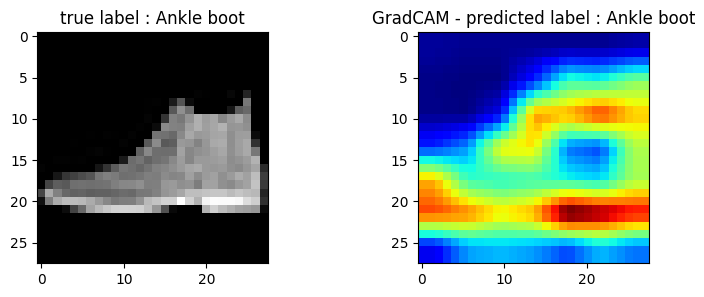

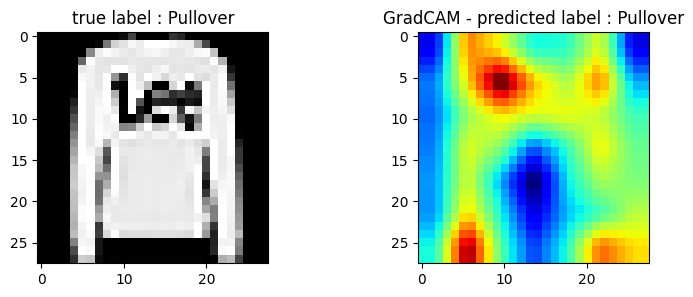

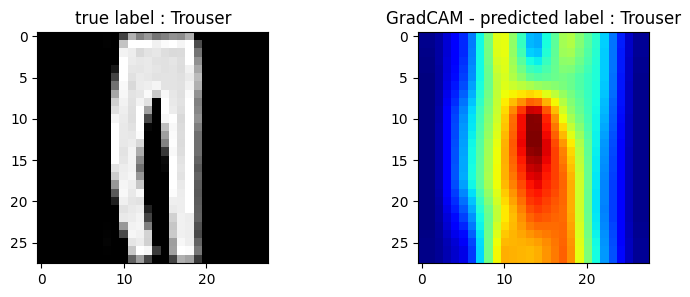

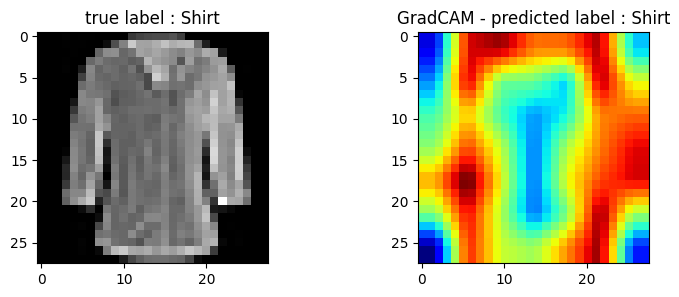

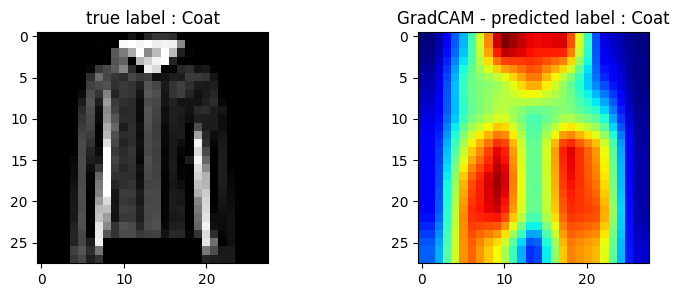

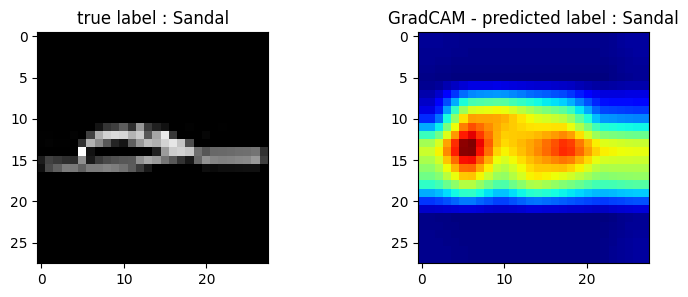

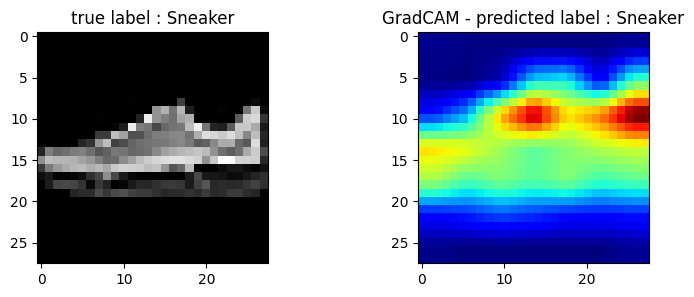

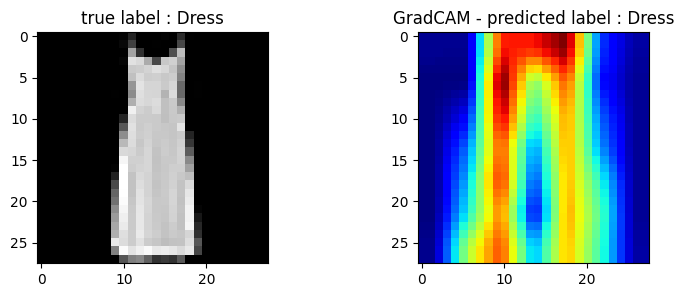

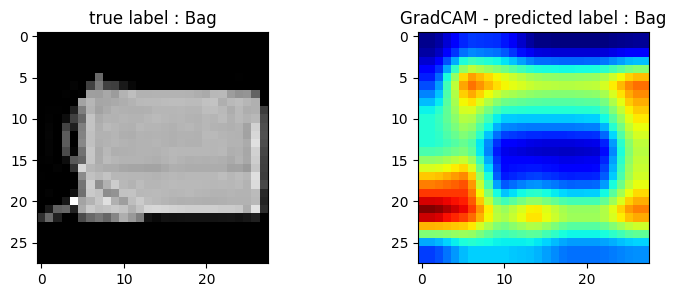

In [ ]:
for i in range(9):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].imshow(imgs[i], cmap="gray");  axes[0].set_title(f"true label : {classes[ys[i]]}")
    axes[1].imshow(cams[i], cmap="jet");   axes[1].set_title(f"GradCAM - predicted label : {classes[preds[i]]}")

Where is GradCAM providing explainability - where not ? Can you identify regions highlighted by the GradCAM that are specific to the type of clothes ?

> Among the different types of shoes, GradCAM highlights the lower or upper part of the shoe, suggesting that the overall silhouette is a more important feature  than laces for example. For elongated clothes like dresses and trousers, GradCAM shows that the model relies on their vertical structure to distinguish them. In the case of the bag, the model focuses on its corners. However, one might expect shirts and pullovers to produce similar heatmaps given their shared features (e.g. sleeves, neckline) yet GradCAM shows that the model captures structural differences between them, confirming that it has learned class-specific patterns rather than generic clothing features.